# YOLO OCR LiLT Evaluation

Batch evaluation for the invoice pipeline:
YOLO text detection -> EasyOCR recognition -> fine-tuned LiLT key information extraction.

## 1. Configuration

In [7]:
from pathlib import Path

from evaluate_yolo_ocr_lilt import EvaluationConfig, evaluate

config = EvaluationConfig(
    images_dir=Path("generated_invoices/images"),
    annotations_dir=Path("generated_invoices/annotations"),
    yolo_model=Path("yolo26_text-detection.pt"),
    lilt_model=Path("lilt_arabic_best"),
    output_dir=Path("evaluation_output"),
    preprocess_mode="none",
    yolo_conf=0.10,
    yolo_iou=0.45,
    yolo_imgsz=1280,
    warmup_runs=1,
    strip_diacritics=True,
    punctuation_cleanup=False,
)
config

EvaluationConfig(images_dir=PosixPath('generated_invoices/images'), annotations_dir=PosixPath('generated_invoices/annotations'), yolo_model=PosixPath('yolo26_text-detection.pt'), lilt_model=PosixPath('lilt_arabic_best'), output_dir=PosixPath('evaluation_output'), preprocess_mode='none', reading_direction='rtl', yolo_conf=0.1, yolo_iou=0.45, yolo_imgsz=1280, crop_padding=4, min_ocr_conf=0.05, max_seq_length=512, warmup_runs=1, strip_diacritics=True, punctuation_cleanup=False, device='cpu')

## 2. Run Full Evaluation

This creates `ground_truths.json`, runs inference on every matching image, and writes all metric files.

In [8]:
evaluation = evaluate(config)

Using CPU. Note: This module is much faster with a GPU.


Created ground truths for 8 documents.
Loading models on cpu...


Loading weights: 100%|█████████████████████████████████████████████████████| 400/400 [00:00<00:00, 2114.67it/s]


Warmup runs: 1
Warmup complete.
[1/8] Processing augmented_invoice_0000.jpg
  total=22.05s
[2/8] Processing augmented_invoice_0001.jpg
  total=26.26s
[3/8] Processing augmented_invoice_0002.jpg
  total=21.78s
[4/8] Processing augmented_invoice_0003.jpg
  total=23.33s
[5/8] Processing augmented_invoice_0004.jpg
  total=19.35s
[6/8] Processing augmented_invoice_0005.jpg
  total=25.34s
[7/8] Processing augmented_invoice_0006.jpg
  total=29.16s
[8/8] Processing augmented_invoice_0007.jpg
  total=30.50s

Evaluation Summary
CER                 : 0.5221
WER                 : 0.7376
Exact Match micro   : 0.1296
Exact Match macro   : 0.0955
Edit Accuracy micro : 0.2597
Edit Accuracy macro : 0.1850
Token F1 micro      : 0.7329
Token F1 macro      : 0.2926
Token F1 weighted   : 0.7513
mAP@0.5             : 0.9979
mAP@0.5:0.95        : 0.9533
Mean IoU            : 0.9245
Avg Latency         : 24.7224s
Throughput          : 0.0404 pages/sec

Saved Files
evaluation_output/ground_truths.json
evaluati

## 3. Console Summary

In [9]:
print((config.output_dir / "summary.txt").read_text(encoding="utf-8"))

Evaluation Summary
CER                 : 0.5221
WER                 : 0.7376
Exact Match micro   : 0.1296
Exact Match macro   : 0.0955
Edit Accuracy micro : 0.2597
Edit Accuracy macro : 0.1850
Token F1 micro      : 0.7329
Token F1 macro      : 0.2926
Token F1 weighted   : 0.7513
mAP@0.5             : 0.9979
mAP@0.5:0.95        : 0.9533
Mean IoU            : 0.9245
Avg Latency         : 24.7224s
Throughput          : 0.0404 pages/sec

Saved Files
evaluation_output/ground_truths.json
evaluation_output/evaluation_results.json
evaluation_output/per_sample_results.csv
evaluation_output/error_analysis.csv
evaluation_output/field_extraction_failures.csv
evaluation_output/confusion_matrix.png



## 4. Per-Sample Results

In [10]:
import pandas as pd

per_sample = pd.read_csv(config.output_dir / "per_sample_results.csv")
per_sample

,doc_id,image_path,num_detections,num_ocr_tokens,num_entities,cer,wer,latency_s,detection_s,ocr_s,lilt_s,gpu_memory_mb
0,augmented_invoice_0000,generated_invoices/images/augmented_invoice_00...,89,243,52,0.548205,0.746835,22.053798,1.088392,20.295847,0.616362,NaN
1,augmented_invoice_0001,generated_invoices/images/augmented_invoice_00...,87,212,39,0.556470,0.789474,26.259160,1.099721,24.457004,0.646933,NaN
2,augmented_invoice_0002,generated_invoices/images/augmented_invoice_00...,78,225,43,0.494226,0.735202,21.784397,1.202411,19.895405,0.632347,NaN
3,augmented_invoice_0003,generated_invoices/images/augmented_invoice_00...,74,246,51,0.531271,0.737288,23.332070,1.190191,21.441154,0.645362,NaN
4,augmented_invoice_0004,generated_invoices/images/augmented_invoice_00...,62,182,40,0.496241,0.706827,19.350409,1.166193,17.487165,0.640610,NaN
5,augmented_invoice_0005,generated_invoices/images/augmented_invoice_00...,98,233,44,0.516422,0.707937,25.339538,1.201462,23.441525,0.638367,NaN
6,augmented_invoice_0006,generated_invoices/images/augmented_invoice_00...,65,222,36,0.539432,0.744828,29.161767,1.148028,26.936258,0.909020,NaN
7,augmented_invoice_0007,generated_invoices/images/augmented_invoice_00...,75,212,37,0.496865,0.734940,30.497726,1.835565,27.984976,0.568999,NaN


## 5. Field Failures

In [11]:
failures = pd.read_csv(config.output_dir / "field_extraction_failures.csv")
failures.head(30)

,doc_id,field,gt,prediction,exact_match,edit_accuracy
0,augmented_invoice_0000,issue_datetime,2024-09-14,14/09/2024,0,0.200000
1,augmented_invoice_0000,subtotal,4754.53,"4,754.53",0,0.857143
2,augmented_invoice_0000,tax,709.61,"4,730.76",0,0.000000
3,augmented_invoice_0000,total,5440.37,"5,440.37",0,0.857143
4,augmented_invoice_0000,street_address,989 المهنا Circle,709.61,0,0.058824
5,augmented_invoice_0000,recipient_phone,+966 51 142 7614,0537245332,0,0.125000
6,augmented_invoice_0000,branch_name,مكة - العوالي,NaN,0,0.000000
7,augmented_invoice_0000,invoice_type,شبكة,NaN,0,0.000000
8,augmented_invoice_0000,invoice_number,01189,NaN,0,0.000000
9,augmented_invoice_0000,customer_number,96081,5,0,0.000000


## 6. Worst OCR Examples

In [12]:
worst_cer = pd.read_csv(config.output_dir / "worst_cer_examples.csv")
worst_wer = pd.read_csv(config.output_dir / "worst_wer_examples.csv")
display(worst_cer.head(10))
display(worst_wer.head(10))

,doc_id,metric_scope,field,gt,prediction,cer,wer,edit_distance_chars,edit_distance_words
0,augmented_invoice_0006,ocr_field,street_address,832 حجار Wells Apt. 685,Apt Apt 685 685 العنوان : : 832 832 حجار,1.521739,1.666667,35,10
1,augmented_invoice_0001,ocr_field,tax,101.52,52./10 ريال,1.500000,5.000000,9,5
2,augmented_invoice_0004,ocr_field,website,al.com,: الموقع,1.333333,1.000000,8,3
3,augmented_invoice_0003,ocr_field,email,qsmal-bn-zfr@example.net,zfr@example net : البريد الالكتروني,1.250000,0.888889,30,8
4,augmented_invoice_0001,ocr_field,discount,6.84,6.84 ربال,1.250000,1.000000,5,1
5,augmented_invoice_0002,ocr_field,shipping_recipient_company,فصيل Group,الشركة : فصيل,1.200000,1.500000,12,3
6,augmented_invoice_0007,ocr_field,invoice_ref,INV-0928-2023,|N|-0928-2023 |NV-0928-2023,1.153846,2.333333,15,7
7,augmented_invoice_0005,ocr_field,pos_phone_number,0582890472,- الهاتف : 0582890472,1.100000,3.000000,11,3
8,augmented_invoice_0006,ocr_field,shipping_street_address,5999 ضاحي Flat,العنوان : 5999 ضاحي,1.071429,1.000000,15,3
9,augmented_invoice_0002,ocr_field,street_address,087 حمزة Gateway,العنوان : 087 حمزة,1.062500,1.000000,17,3


,doc_id,metric_scope,field,gt,prediction,cer,wer,edit_distance_chars,edit_distance_words
0,augmented_invoice_0001,ocr_field,tax,101.52,52./10 ريال,1.500000,5.0,9,5
1,augmented_invoice_0000,ocr_field,subtotal,4754.53,"4,754.53 ربال",0.857143,4.0,6,4
2,augmented_invoice_0000,ocr_field,net_amount,4730.76,"4,730.76 ربال",0.857143,4.0,6,4
3,augmented_invoice_0003,ocr_field,total,6545.36,"6,545.36 ريال",0.857143,4.0,6,4
4,augmented_invoice_0004,ocr_field,subtotal,5123.43,"5,123.43 ريال",0.857143,4.0,6,4
5,augmented_invoice_0004,ocr_field,total,5891.94,"5,891.94 ريال",0.857143,4.0,6,4
6,augmented_invoice_0003,ocr_field,subtotal,5691.62,"5,691.62 ريال",0.857143,4.0,6,4
7,augmented_invoice_0002,ocr_field,tax,1351.38,"1,351.38 ريال",0.857143,4.0,6,4
8,augmented_invoice_0002,ocr_field,total,10360.61,"10,360.61 ريال",0.750000,4.0,6,4
9,augmented_invoice_0002,ocr_field,subtotal,9009.23,"9,009.23 ريال",0.857143,4.0,6,4


## 7. Confusion Matrix

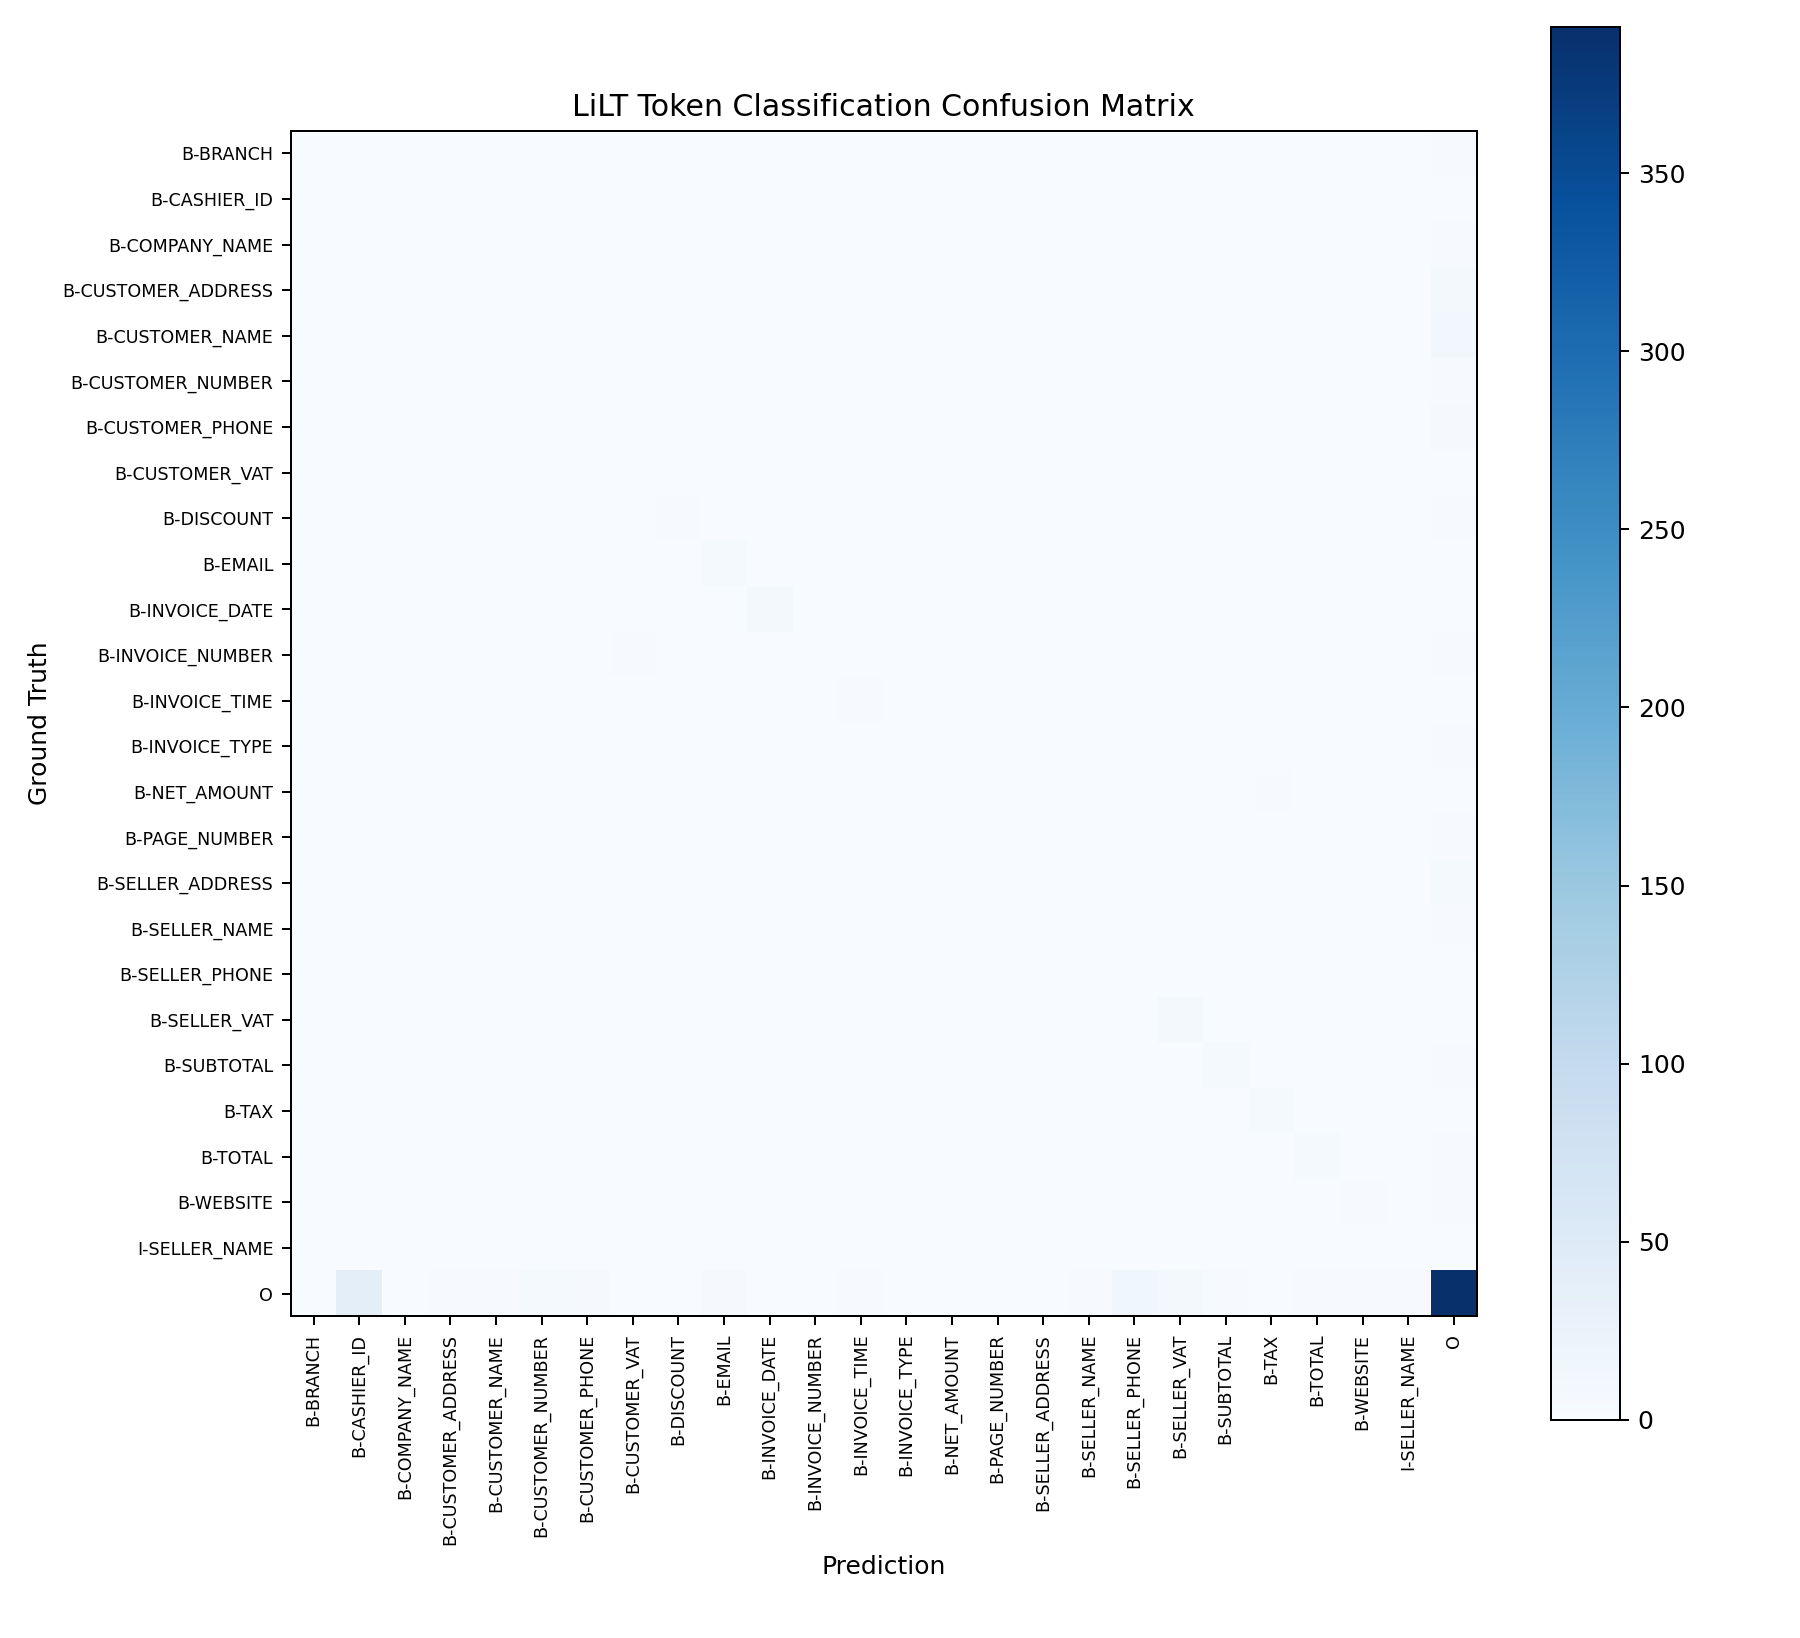

In [13]:
from IPython.display import Image, display

display(Image(filename=str(config.output_dir / "confusion_matrix.png")))

## 8. Saved Visualizations

In [14]:
from pathlib import Path

for image_path in sorted((config.output_dir / "samples").glob("*/*.jpg")):
    print(image_path)

evaluation_output/samples/augmented_invoice_0000/detections.jpg
evaluation_output/samples/augmented_invoice_0000/lilt_fields.jpg
evaluation_output/samples/augmented_invoice_0000/preprocessed.jpg
evaluation_output/samples/augmented_invoice_0001/detections.jpg
evaluation_output/samples/augmented_invoice_0001/lilt_fields.jpg
evaluation_output/samples/augmented_invoice_0001/preprocessed.jpg
evaluation_output/samples/augmented_invoice_0002/detections.jpg
evaluation_output/samples/augmented_invoice_0002/lilt_fields.jpg
evaluation_output/samples/augmented_invoice_0002/preprocessed.jpg
evaluation_output/samples/augmented_invoice_0003/detections.jpg
evaluation_output/samples/augmented_invoice_0003/lilt_fields.jpg
evaluation_output/samples/augmented_invoice_0003/preprocessed.jpg
evaluation_output/samples/augmented_invoice_0004/detections.jpg
evaluation_output/samples/augmented_invoice_0004/lilt_fields.jpg
evaluation_output/samples/augmented_invoice_0004/preprocessed.jpg
evaluation_output/samples